In [ ]:
# Part a)
#i)
import pandas as pd
import matplotlib.pyplot as plt
data_path="HW1_data/data/question_5_data/train.csv"
df = pd.read_csv(data_path)
print (f"Shape: {df.shape}")
print (f"Data types:\n{df.dtypes}")
print ("\n ================= First 5 rows =================\n")
print(df.head())

Shape: (8693, 14)
Data types:
PassengerId         str
HomePlanet          str
CryoSleep        object
Cabin               str
Destination         str
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name                str
Transported        bool
dtype: object

 ================= First 5 rows =================

  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maha

6 are numerical and 8 are categorical (Considering ID a string)

--- Missing Data Summary ---
              Missing Values  Percentage (%)
CryoSleep                217        2.496261
ShoppingMall             208        2.392730
VIP                      203        2.335212
HomePlanet               201        2.312205
Name                     200        2.300702
Cabin                    199        2.289198
VRDeck                   188        2.162660
Spa                      183        2.105142
FoodCourt                183        2.105142
Destination              182        2.093639
RoomService              181        2.082135
Age                      179        2.059128
PassengerId                0        0.000000
Transported                0        0.000000


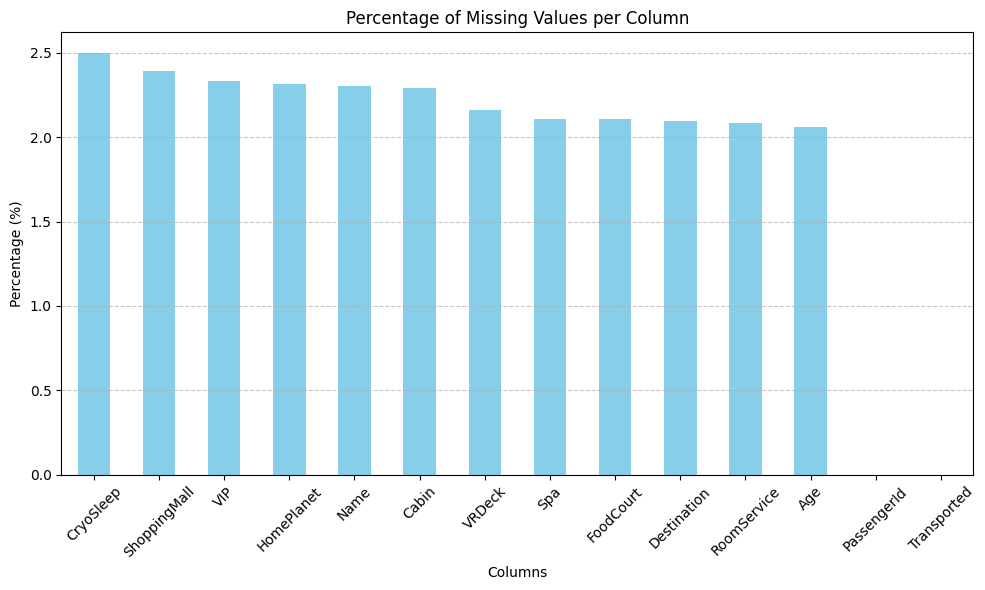

In [4]:
#ii)
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100

#Create DataFrame
missing_df = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)': missing_percentages
}).sort_values(by='Missing Values', ascending=False)


print("--- Missing Data Summary ---")
print(missing_df)

# 4. Visualize the results
plt.figure(figsize=(10, 6))
missing_df['Percentage (%)'].plot(kind='bar', color='skyblue')
plt.title('Percentage of Missing Values per Column')
plt.ylabel('Percentage (%)')
plt.xlabel('Columns')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# iii)
num_transported = (df['Transported']==True)
print (f"Percentage of passengers transported: {100*num_transported.sum()/df['Transported'].count():.2f}%")

Percentage of passengers transported: 50.36%


The dataset is roughly balanced

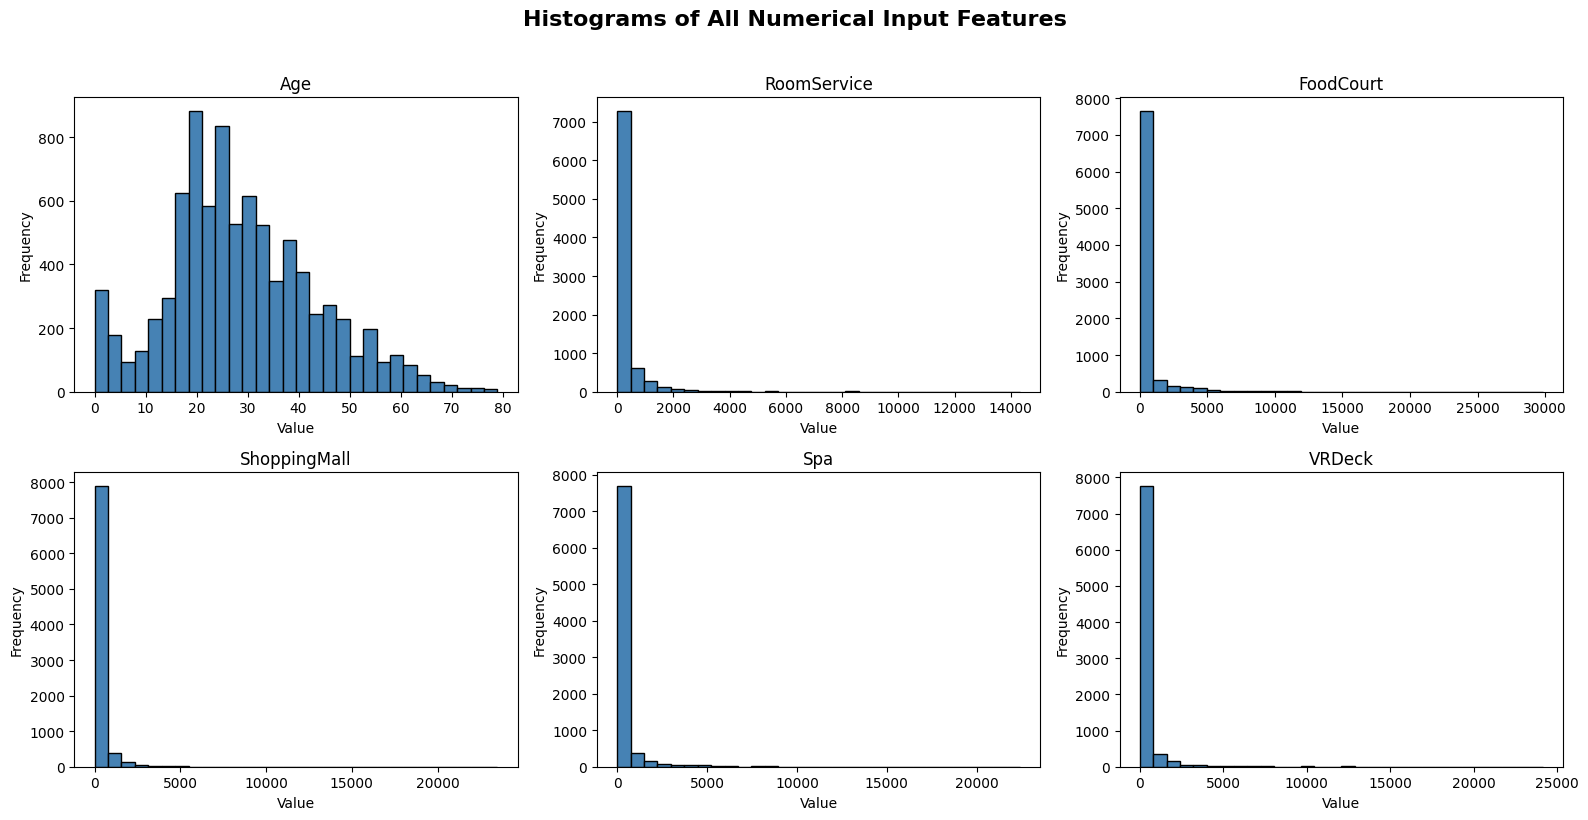

In [16]:
# iv)
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Determine grid size for subplots
n_features = len(numerical_features)
ncols = 3
nrows = (n_features + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    # Dropping NaN values for plotting
    axes[i].hist(df[feature].dropna(), bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(feature, fontsize=12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Histograms of All Numerical Input Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


All the features except for age are very heavily right skewed, which means most passengers did not have access to those in the spaceship

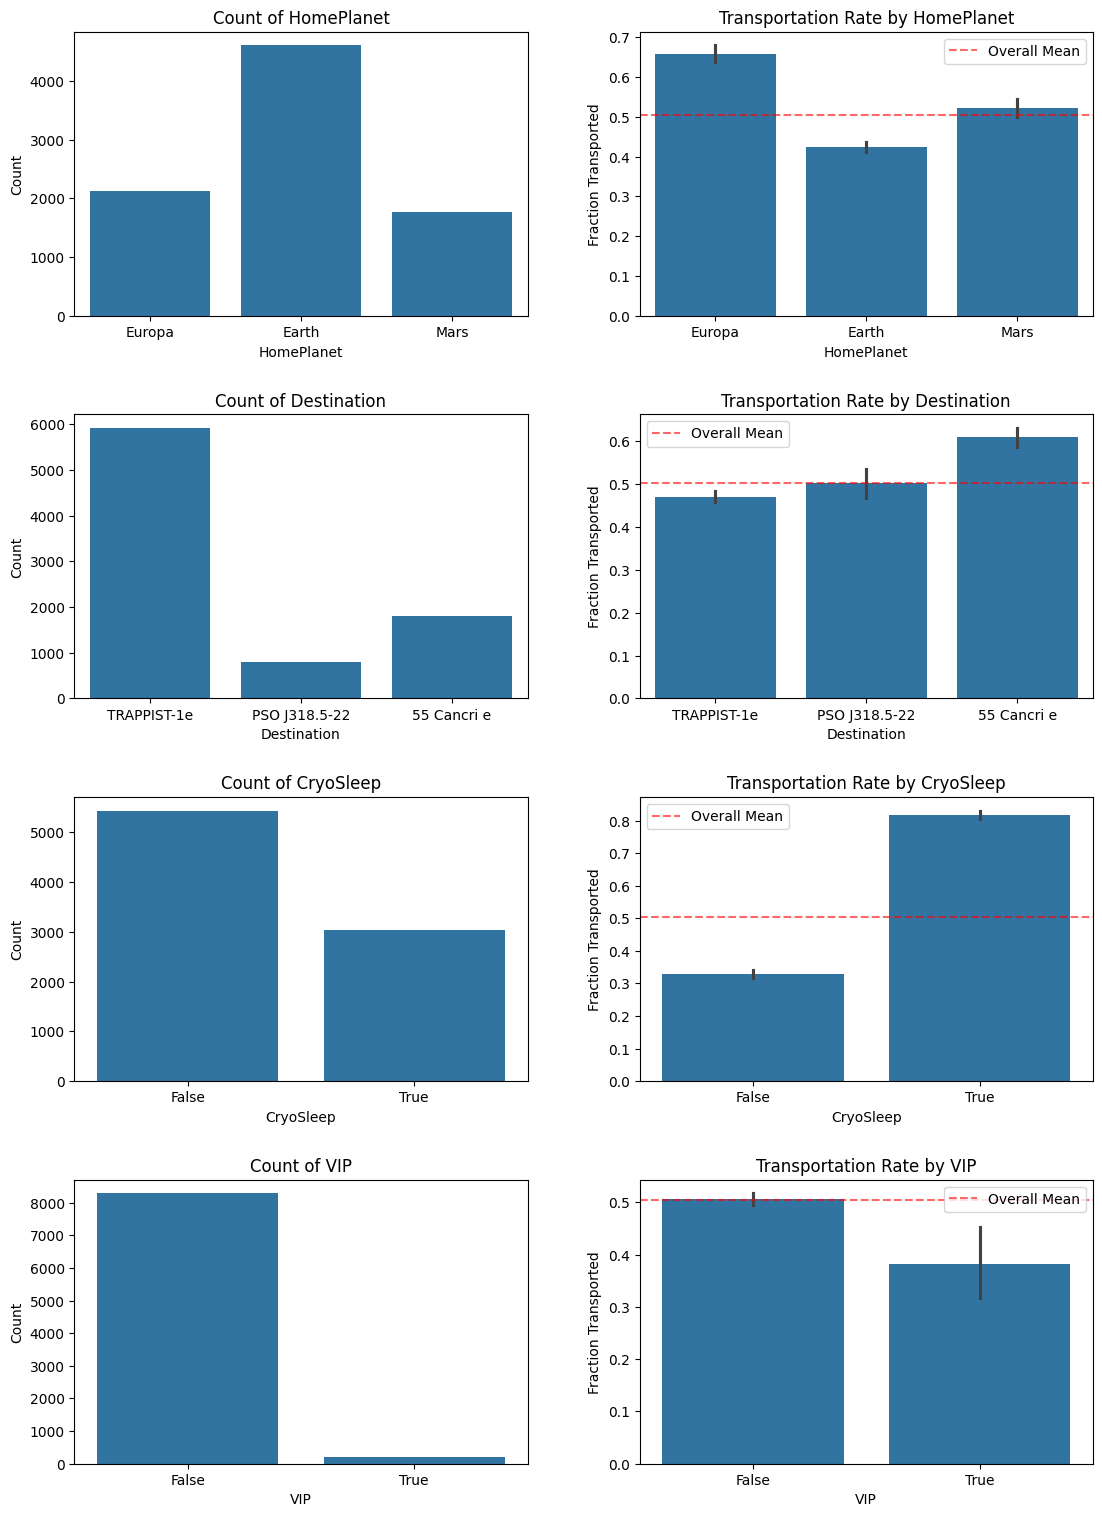

In [18]:
# v)
import seaborn as sns

categorical_features = ['HomePlanet', 'Destination', 'CryoSleep', 'VIP']

# Set up the matplotlib figure
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 16))
fig.tight_layout(pad=5.0)

for i, col in enumerate(categorical_features):
    
    sns.countplot(data=df, x=col, ax=axes[i, 0])
    axes[i, 0].set_title(f'Count of {col}', fontsize=12)
    axes[i, 0].set_ylabel('Count')
    
    sns.barplot(data=df, x=col, y='Transported', ax=axes[i, 1])
    axes[i, 1].set_title(f'Transportation Rate by {col}', fontsize=12)
    axes[i, 1].set_ylabel('Fraction Transported')
    # Optional: Add a horizontal line representing the baseline transportation rate
    baseline_rate = df['Transported'].mean()
    axes[i, 1].axhline(baseline_rate, color='red', linestyle='--', alpha=0.6, label='Overall Mean')
    axes[i, 1].legend()

plt.show()

The Cryo Sleep category appears to be the most predictive of the target since around 80% of passengers in Cryo Sleep were transported

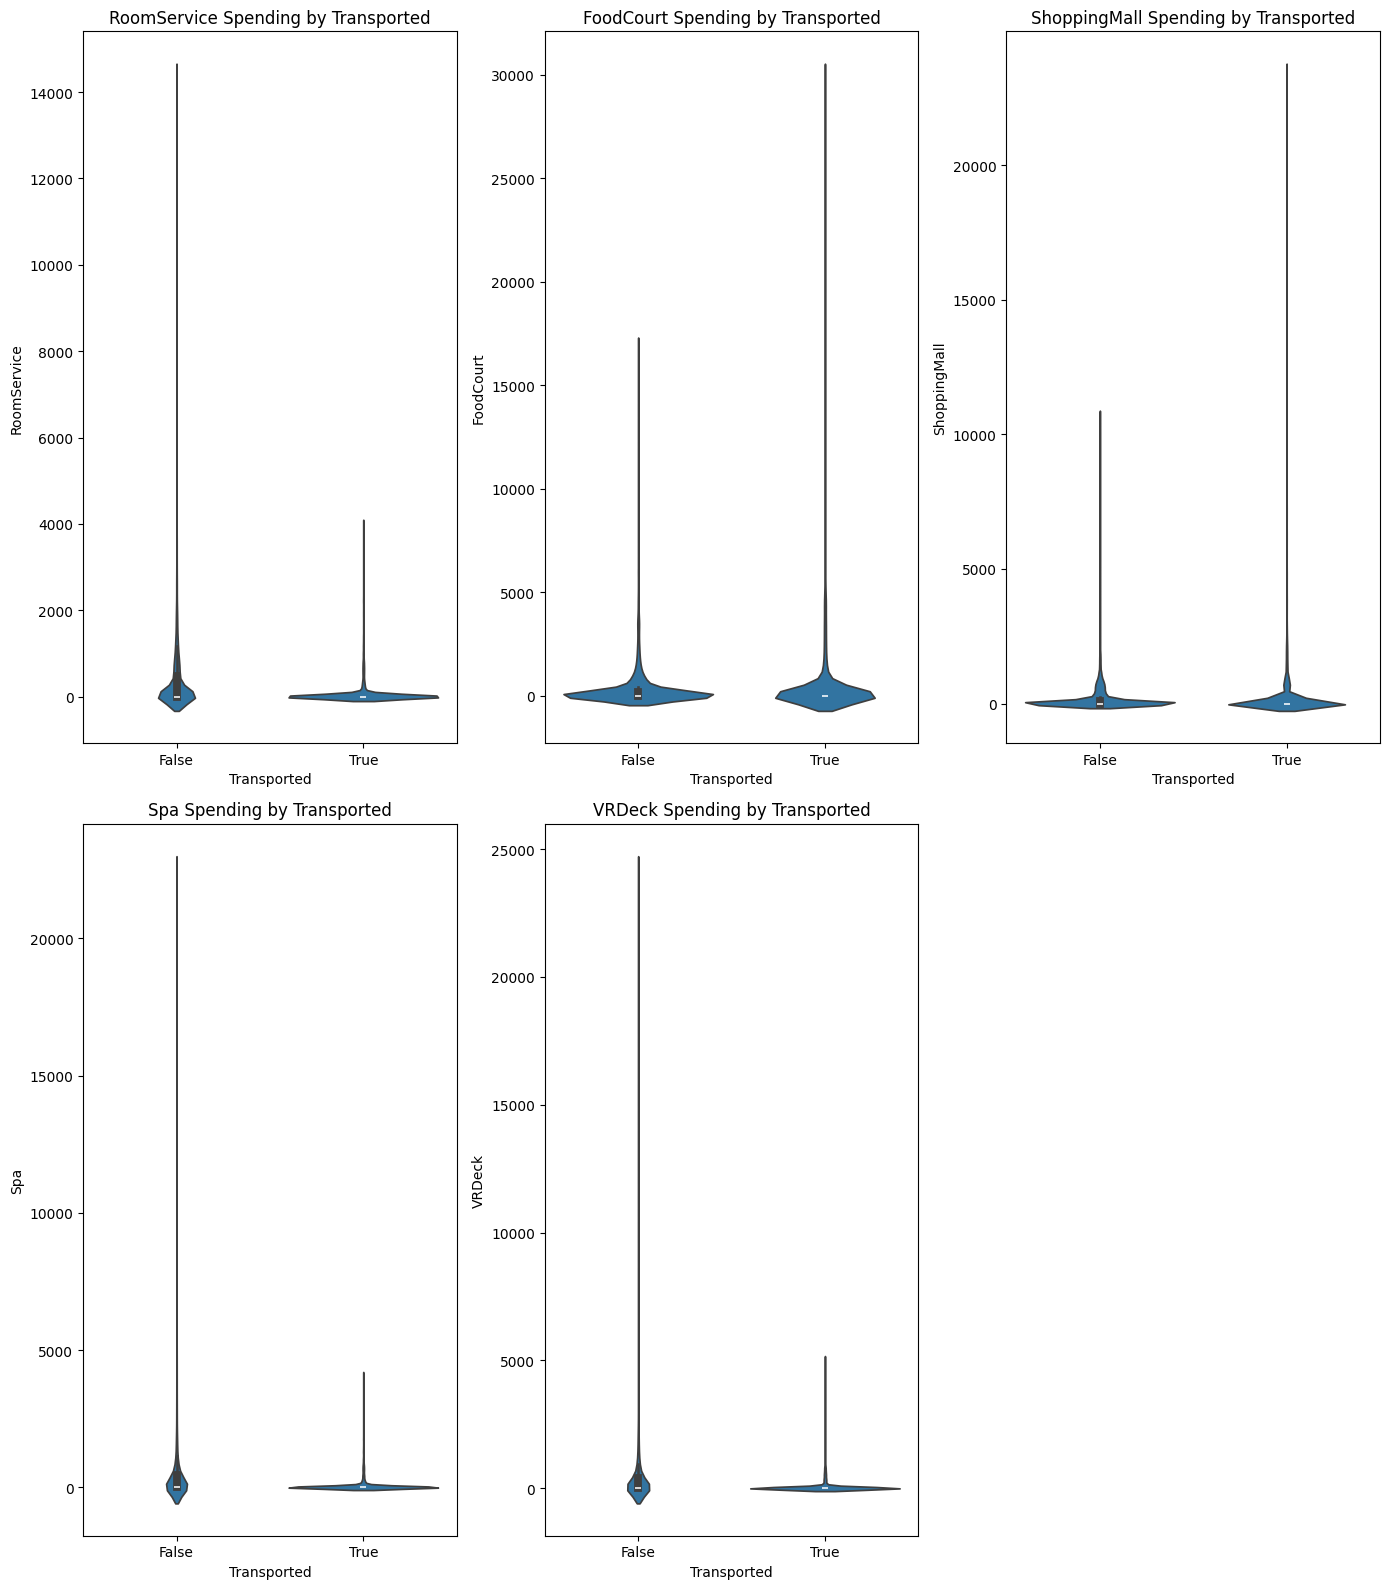

In [25]:
# vi)

import numpy as np
spending_features = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Set up the matplotlib figure
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(spending_features):
    # Using a violin plot. Box plot can be used by swapping sns.violinplot with sns.boxplot
    # We apply a log transformation (log1p) because spending data is highly right-skewed 
    # with many passengers spending 0. This makes the plots much easier to read.
    sns.violinplot(
        data=df, 
        x='Transported', 
        y=df[col], # log(1 + x) to handle 0s
        ax=axes[i], 
    )
    axes[i].set_title(f'{col} Spending by Transported', fontsize=12)
    axes[i].set_ylabel(f'{col}')

# Remove the empty 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

Transported passengers tend to spend significantly less, which reinforces the hypothesis that being in cryo sleep is one of the most important factors to predict the target (since sleeping passengers do not spend)

In [ ]:
# Part b)
# i)